*Introduction to Python Programming for Earth Scientists*

*Session #10, 29 Sep 2025*

# Plotting with Matplotlib; NumPy practice

### Today's notebooks

`10a_practice_with_numpy` and `10b_plotting_matplotlib`

(Please hand in both)

### Today's

- Housekeeping
  - Code paper #2 due date extended to Monday 6 Oct
  - Lightning (1-slide) presentations on Python packages starting Wednesday
  - Questions on code paper #2?
  - Use of ChatGPT or other LLMs: must acknowledge in writing and state what you used and how you used it
- NumPy practice / review notebook (see `10a_practice_with_numpy.ipynb`)
- Introduction to plotting Matplotlib
- If time, in-class work on Code paper 2
- Regroup and wrap up

### Learning goals for Matplotlib

- Learn about Matplotlib and be able to import the pyplot sub-package.
- Know how to do line plotting basics for lists or arrays.
- Know how to annotate a plot: add axis labels, add a title to a plot, vary the line/marker style and color.
- Be able to create a x,y scatter plot, and know how it is different. 
- Learn how to plot multiple quantities on the same plot, and use a legend
- Learn how to plot histograms with variable number of bins

### Geoscience topics

- CO2 concentration measurements at Manua Loa, Hawaii
- Ice cores as a proxy for long-term climate evolution


## What is Matplotlib?

Matplotlib is a plotting library. It allows you to make plots for reports/papers from your data. We will start off with the subpackage `pyplot`.

In [1]:
# Load the matplot lib plotting package
import matplotlib.pyplot as plt

### Line plots and their annotation: the Keeling curve as an example

The first systematic and ongoing measurements of CO$_2$ concentration in the atmosphere were started in 1958 by Dr. Charles David Keeling (Scripps Oceanography). The carbon dioxide data on Mauna Loa now constitute the longest record of direct measurements of CO$_2$ in the atmosphere. NOAA now maintains a longterm monitoring program of sampling of CO$_2$ across the globe.<br>

Data are reported as a 'dry air mole fraction', defined as the number of molecules of carbon dioxide divided by the number of all molecules in air after water vapor has been removed. The mole fraction is expressed as parts per million (ppm). Example: 0.000400 (= 0.04%) is expressed as 400 ppm.

See: [https://gml.noaa.gov/ccgg/trends/data.html](https://gml.noaa.gov/ccgg/trends/data.html)

In [2]:
# Line plot using lists

# Here are annual average CO2 concentrations for 
# the years 1960, 1970, ... 2020. They are organized
# into two lists: one for year, and one for CO2 in ppm.
year = [1960, 1970, 1980, 1990, 2000, 2010, 2020]
CO2ppm = [316.91, 325.68, 338.76, 354.45, 369.71, 390.1, 414.21]

print(year, CO2ppm)

[1960, 1970, 1980, 1990, 2000, 2010, 2020] [316.91, 325.68, 338.76, 354.45, 369.71, 390.1, 414.21]


`pyplot` has a function called `plot()`. The simplest way to plot our CO$_2$ values is to call this function and pass it a single list: the one containing our CO$_2$ data:

`plt.plot(CO2ppm)`

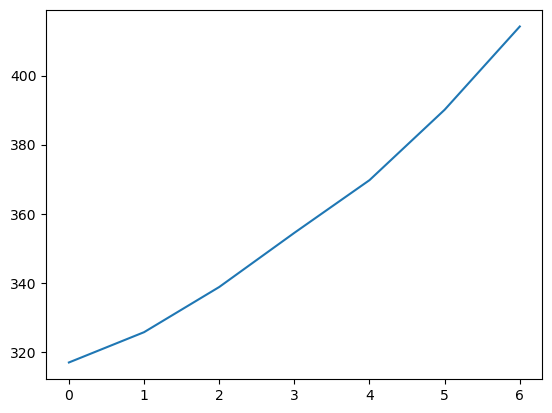

In [3]:
plt.plot(CO2ppm)

When `plt.plot()` is called with a single input argument, it puts the values on the y-axis and their numbering on the x-axis.

In this case, it would be better to have the year of measurement on the x-axis. We can do this by passing *two* lists to `plot()`: one for the year (x-axis), and one for the CO$_2$ concentration (y-axis).

In the example below, the `pyplot` functions `xlabel()` and `ylabel()` are used to label the two axes.

```
plt.plot(year, CO2ppm)

plt.ylabel('CO2 in ppm')
plt.xlabel('year')
```
When you pass *two* positional arguments to `plot()`, the first is interpreted as the x values and the second as the y values.

Text(0, 0.5, 'CO2 (ppm)')

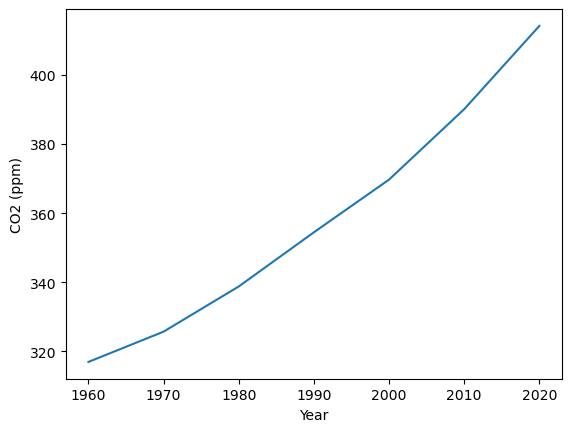

In [5]:
plt.plot(year, CO2ppm)

plt.xlabel("Year")
plt.ylabel("CO2 (ppm)")

Now we can see the years, and we know what is on the x and y axes. But there's no title to the plot, and it's hard to make out where the actual data points are.

For the third (optional) positional argument to `plot()`, you can pass a string that tells `plot()` what kind of line and/or symbol to use, and what color they should be. For example, if I want to plot my data points as open circles connected by a line, and using the default color, I pass the string `-o`. The `-` character tells `plot()` to draw a solid line between data points, and the `o` character tells it to plot each symbol with an open circle.

To add a title to my plot, I pass a string to the `pyplot` function `title`.

```
plt.plot(year, CO2ppm, '-o')

plt.ylabel('CO2 concentration (ppm)')
plt.xlabel('Year')
plt.title('Decadal CO2 concentration at Manua Loa Observatory')
```

Text(0.5, 1.0, 'Decadal CO2 concentration at Mauna Loa')

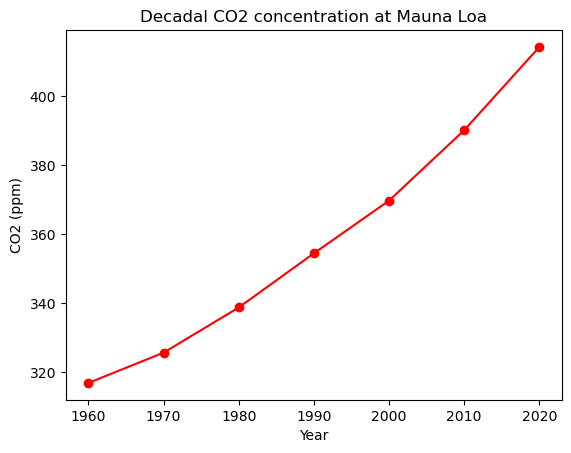

In [7]:
plt.plot(year, CO2ppm, 'r-o')
plt.xlabel('Year')
plt.ylabel('CO2 (ppm)')
plt.title('Decadal CO2 concentration at Mauna Loa')

Here is an arbitrary example , illustrating how you can change the plot symbol and color:
```
t = np.arange(0., 5., 0.2)

# red dashes, blue squares and green triangles
plt.plot(t, t, 'r--', t, t**2, 'bs', t, t**3, 'g^')
plt.show()
```

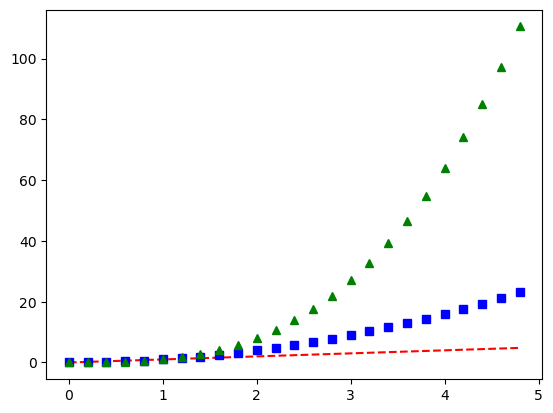

In [12]:
import numpy as np

t = np.arange(0., 5., 0.2)

plt.plot(t, t, 'r--')
plt.plot(t, t**2, 'bs')
plt.plot(t, t**3, 'g^')

### Scatter Plots

A scatter plot is one that shows individual points in (x, y) space. The `scatter()` function is very similar to `plot()`, except that it draws point symbols instead of lines by default.

The following example uses annual average CO$_2$ data from the Mauna Loa observatory. (This is also one of the two datasets used in Code Paper #2.)

In [13]:
import numpy as np
    
# here I use numpy functions loadtxt() (we'll learn more about
# this in classes to come)
arr = np.loadtxt(
    "co2_annmean_mlo_1959_2024.txt",
    comments="#",
)

To find out the shape and size of a NumPy array, we can use the `shape` attribute. Try:
```
print(arr.shape)
```

The array should have 3 columns. The first column is the year, the second is the annual average atmospheric CO$_2$ for that year (in ppm), and the third column is the measurement uncertainty (also in ppm).

Use array indexing to find out the first and last years in the dataset.

Use array indexing to find out the CO$_2$ concentration for these years.

In [14]:
print(arr.shape)

(66, 3)


Below is code to make a scatter plot, which displays x versus y as single data points. Scatter plots give a better idea of how many data points were used to establish the plot.
```
plt.scatter(arr[:,0], arr[:,1])
plt.ylabel('CO2 in ppm')
plt.xlabel('year')
plt.title('Yearly average CO2 concentration at Manua Loa Observatory')
plt.show()
```

Text(0, 0.5, 'CO2 concentration')

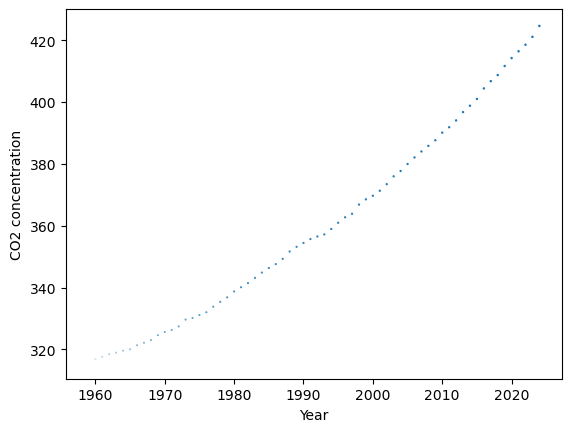

In [26]:
plt.scatter(arr[:,0], arr[:,1], 0.01 * (arr[:,0] - 1959))
plt.xlabel('Year')
plt.ylabel('CO2 concentration')

### <span style="color: green;">IN-CLASS PRACTICE</span>

Use `help(plt.scatter)` to find out what you can change in scatter plots



Using the example codes above, change the Keeling curve plot create a subset array of the years 2000-2024.

In [27]:
for i in range(66):
    if arr[i,0] == 2000:
        print("Found it! The year 2000 is row", i)

Found it! The year 2000 is row 41


In [28]:
print(arr[-1,:])

[2.0240e+03 4.2461e+02 1.2000e-01]


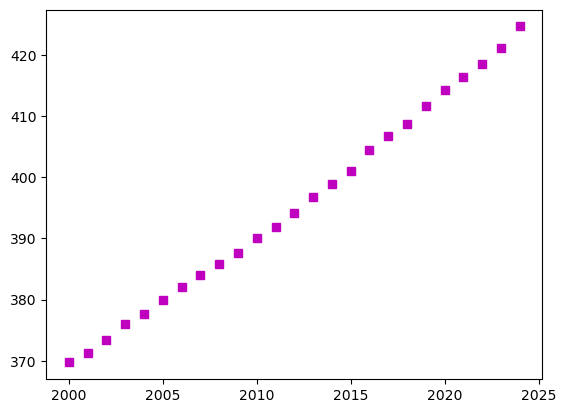

In [29]:
plt.plot(arr[41:,0], arr[41:,1], 'ms')

Plot the full data set with black dots, and the subset from 2000-2024 as green triangles.

Find and print the CO$_2$ concentration in the years 2000 and 2024.

Then calculate and print the change over those 24 years.

Create an array using `linspace()` that represents a linear increase in CO$_2$ concentration, starting from its value in the year 2000, and extending to 2024.

Plot this data on top of the CO$_2$ measurements using a red line.


###  Histograms

A *histogram* shows the distribution of values in a dataset. The x-axis represents *bins* of different values. For example, a histogram might have one bin for values between 0 and 0.1, another for values between 0.1 and 0.2, etc. The y-axis shows the number of values that fall within each bin. If you add up each of these, it should sum to the total number of points in the dataset.

Here is an arbitrary dataset, displayed using the Pyplot `histogram()` function:
```
mylist = [
    0.1, 0.01, 0.4, 0.03, 0.05, 0.03, 0.06, 0.02, 0.01, 0.42, 
    0.02, 0.05, 0.1, 0.02, 0.055, 0.2, 0.03, 0.05, 0.06, 0.02, 
    0.01, 0.42, 0.02, 0.05, 0.1, 0.02
]
plt.hist(mylist)
```


You can also plot the cumulative distribution, which shows the number of values *smaller* than a given value.
```
plt.hist(mylist, cumulative=1)
```
Or the reverse: the number of points *larger* than a given value:
```
plt.hist(mylist, cumulative=-1)
```

## <span style="color: purple;">Motivating Problem</span>

### <span style="color: purple;">Ice Cores as Climate Data Records</span>

Modern-day observations can show how greenhouse gasses have been changing over the last few decades. But how do we know whether this is unusual over Earth's climate history?

This is where the accumulation zone of glaciers comes in handy - if there is no melt in the upper regions of a glacier, it keeps accumulating layers of annual snow fall in those areas. This is even more so the case for ice-sheets that have a dome shape and flow most rapidly in the lower regions.

Clues to past climates can be revealed by drilling into glaciers and ice sheets. The extracted ice cylinders, sometimes taken from several kilometers below the surface, show evidence of atmospheric composition, volcanic eruptions, dust storms, even wind patterns.

Since the 1960's scientists have been collecting ice cores from Greenland, Antarctica and mountain glaciers. 
The cores are preserved as 1 m long segments, investigated for gas contents, water chemistry and isotopes, dust traces, etc. The cores are stored in special facilities with freezers.

In 1993, after five years of drilling, the Greenland 'GISP2' project penetrated through the ice sheet and 1.55 meters into bedrock, recovering an ice core 3,053 meters long.

Here we will take a first look at the data of one of the segments of this core.

One of the important analyses that is done for an ice core is counting of the annual layers of ice. Each year leaves a distinct layer (even if these layers get compressed over time).

The data are available here:

[https://icecores.org/inventory/gisp2](https://icecores.org/inventory/gisp2)

### <span style="color: green;">IN-CLASS PRACTICE</span>

Practice working one of the datasets from Code Paper #2. This datafile contains CO$_2$ measurements from ice cores in Antarctica. The two lines of code below will read the data into a 2d NumPy array.

In [ ]:
antco2file = "antarctica2015co2composite-noaa.txt"
antdata = np.loadtxt(antco2file, comments=["#", "a"], skiprows=1)



Find out the size of this array.

Figure out which parts of the array represent:
- time (in years before 1950; negative numbers represent years after 1950),
- CO2 concentration (parts per million, or ppm)
- Concentration uncertainty (also ppm)

Use NumPy functions to print out the mean, minimum, and maximum values of CO2 concentration in the dataset (hint: `mean()`, `amax()`, `amin()`).

Plot a histogram of the CO$_2$ concentration with 20 bins.

Label the x and y-axis, and add a title.


Plot CO$_2$ versus age using black dots. Label x and y axes.

Using the previous dataset on historic CO$_2$ measurements at Mauna Loa, create a new array that contains the **change** in CO$_2$ between years. (Hint: you can do this using the NumPy `diff()` function). Plot the data against year. (Double hint: you'll have one fewer measurement when you difference the data, so try plotting years from array index 1 to the end of the years array.)

### Documentation on matplotlib

[https://matplotlib.org/](https://matplotlib.org/)